In [1]:
import matplotlib.pyplot as plt
from SEPOT import SEPOT
from simulate_SE_POT import simulate_SE_POT
import numpy as np
import sys
from scipy.stats import kstest, expon, probplot
import pandas as pd
import os

In [2]:
threshold = 1.5
years = 10
T = years * 365.0

rand = np.random.randint(0, sys.maxsize)
seed = rand
seed = 3158914176077841016
print(f"Seed: {seed}")

np.set_printoptions(precision=6, suppress=True)
pd.options.display.float_format = '{:.6f}'.format

#--------------------------------------------------
def get_true_params(SE_fun,
                    impact_fun,
                    mark_dist):
    
    if SE_fun == "Exp":
        if impact_fun is None:
            if mark_dist == "GPD":
                # SE_fun = "Exp", impact_fun = None, mark_dist = "GPD"
                mu, K_0, beta, xi, sigma = 0.0063, 0.0446, 0.0531, 0.1157, 0.3870
                true_params = np.array([mu, K_0, beta, xi, sigma])
                true_params_names = ["mu", "K_0", "beta", "xi", "sigma"]
            else:
                # SE_fun = "Exp", impact_fun = "Exp", mark_dist = "SE GPD"
                mu, K_0, beta, xi, phi, eta = 0.0063, 0.0446, 0.0531, 0.1157, 0.3870, 0.0911
                true_params = np.array([mu, K_0, beta, xi, phi, eta])
                true_params_names = ["mu", "K_0", "beta", "xi", "phi", "eta"]
        else:
            if mark_dist == "GPD":
                # SE_fun = "Exp", impact_fun ≠ None, mark_dist = "GPD"
                mu, K_0, beta, alpha, xi, sigma = 0.0063, 0.0446, 0.0531, 0.1388, 0.1157, 0.3870
                true_params = np.array([mu, K_0, beta, alpha, xi, sigma])
                true_params_names = ["mu", "K_0", "beta", "alpha", "xi", "sigma"]
            else:
                # SE_fun = "Exp", impact_fun ≠ None, mark_dist = "SE GPD"
                mu, K_0, beta, alpha, xi, phi, eta = 0.0063, 0.0446, 0.0531, 0.1388, 0.1157, 0.3870, 0.0911
                true_params = np.array([mu, K_0, beta, alpha, xi, phi, eta])
                true_params_names = ["mu", "K_0", "beta", "alpha", "xi", "phi", "eta"]
        branching_ratio = K_0/beta
    else:
        if impact_fun is None:
            if mark_dist == "GPD":
                # SE_fun = "Pow", impact_fun = None, mark_dist = "GPD"
                mu, K_0, gamma, omega, xi, sigma = 0.0063, 0.0446, 0.0331, 1.7983, 0.1157, 0.3870
                true_params = np.array([mu, K_0, gamma, omega, xi, sigma])
                true_params_names = ["mu", "K_0", "gamma", "omega", "xi", "sigma"]
            else:
                # SE_fun = "Pow", impact_fun = None, mark_dist = "SE GPD"
                mu, K_0, gamma, omega, xi, phi, eta = 0.0063, 0.0446, 0.0331, 1.7983, 0.1157, 0.3870, 0.0911
                true_params = np.array([mu, K_0, gamma, omega, xi, phi, eta])
                true_params_names = ["mu", "K_0", "gamma", "omega", "xi", "phi", "eta"]
        else:
            if mark_dist == "GPD":
                # SE_fun = "Pow", impact_fun ≠ None, mark_dist = "GPD"
                mu, K_0, gamma, omega, alpha, xi, sigma = 0.0063, 0.0446, 0.0331, 1.7983, 0.1388, 0.1157, 0.3870
                true_params = np.array([mu, K_0, gamma, omega, alpha, xi, sigma])
                true_params_names = ["mu", "K_0", "gamma", "omega", "alpha", "xi", "sigma"]
            else:
                # SE_fun = "Pow", impact_fun ≠ None, mark_dist = "SE GPD"
                mu, K_0, gamma, omega, alpha, xi, phi, eta = 0.0063, 0.0446, 0.0331, 1.7983, 0.1388, 0.1157, 0.3870, 0.0911
                true_params = np.array([mu, K_0, gamma, omega, alpha, xi, phi, eta])
                true_params_names = ["mu", "K_0", "gamma", "omega", "alpha", "xi", "phi", "eta"]
        branching_ratio = K_0/(gamma * omega)
                
    return true_params, true_params_names, branching_ratio


def get_bounds(SE_fun: str,
               impact_fun: str | None,
               mark_dist: str,
               zero_lb: float = 1e-08,
               ub: float = np.inf,
               ub_power: float = np.inf):
        
    bounds = 3 * [(zero_lb, ub)]
    if SE_fun == "Pow":
        bounds += [(zero_lb, ub_power)]
    if impact_fun is not None:
        bounds += [(zero_lb, ub_power)]
    if mark_dist == "GPD":
        bounds += [(-ub, ub), (zero_lb, ub)]
    else:
        bounds += [(-ub, ub), (zero_lb, ub), (zero_lb, ub)]
    return bounds

Seed: 3158914176077841016


In [3]:
'''SE_funs = ["Exp", "Pow"]
impact_funs = [None, "Exp", "Pow"]
mark_dists = ["GPD", "SE GPD"]


for SE_fun in SE_funs:
    for mark_dist in mark_dists:
        for impact_fun in impact_funs:

            print(f"Testing model: {SE_fun}, {impact_fun}, {mark_dist}...\n")

            true_params, _, _ = get_true_params(SE_fun=SE_fun,
                                                impact_fun=impact_fun,
                                                mark_dist=mark_dist)

            simulator = simulate_SE_POT(T=T,
                                        threshold=threshold,
                                        params=true_params,
                                        SE_fun=SE_fun,
                                        impact_fun=impact_fun,
                                        mark_dist=mark_dist,
                                        seed=seed)
            
            arrival_times, marks = simulator.simulate()
            
            SEPOT_model = SEPOT(SE_fun=SE_fun,
                                impact_fun=impact_fun,
                                mark_dist=mark_dist,
                                arrival_times=arrival_times,
                                marks=marks,
                                T=T,
                                threshold=threshold,
                                seed=seed)
            
            tau_i_s_with_new_comp = SEPOT_model.compensator(starts=np.zeros(shape=(len(arrival_times), ), dtype=float),
                                                            ends=arrival_times,
                                                            params=true_params)
            
            tau_i_s_with_old_comp = np.array([SEPOT_model.compensator(starts=0.0, 
                                                                      ends=arrival_time,
                                                                      params=true_params) for arrival_time in arrival_times]).reshape(-1)
            
            print(f"Abs. Diff. between new taus and old taus:\n{abs(tau_i_s_with_new_comp - tau_i_s_with_old_comp).sum()}\n")

            print(f"Test complete for model: {SE_fun}, {impact_fun}, {mark_dist}!\n")

            print("-"*100)

            
            
            '''

'SE_funs = ["Exp", "Pow"]\nimpact_funs = [None, "Exp", "Pow"]\nmark_dists = ["GPD", "SE GPD"]\n\n\nfor SE_fun in SE_funs:\n    for mark_dist in mark_dists:\n        for impact_fun in impact_funs:\n\n            print(f"Testing model: {SE_fun}, {impact_fun}, {mark_dist}...\n")\n\n            true_params, _, _ = get_true_params(SE_fun=SE_fun,\n                                                impact_fun=impact_fun,\n                                                mark_dist=mark_dist)\n\n            simulator = simulate_SE_POT(T=T,\n                                        threshold=threshold,\n                                        params=true_params,\n                                        SE_fun=SE_fun,\n                                        impact_fun=impact_fun,\n                                        mark_dist=mark_dist,\n                                        seed=seed)\n\n            arrival_times, marks = simulator.simulate()\n\n            SEPOT_model = SEPOT(SE_fun=SE_fun,\n

In [4]:
'''            
        print(f"np.max(preds):\n{np.max(preds)}\n")
        print(f"np.min(preds):\n{np.min(preds)}\n")
        print(f"preds[-1]:\n{preds[-1]}\n")
        print(f"preds[-2]:\n{preds[-2]}\n")

        num_chunks = len(times_chunks)
        QPS = 2/num_chunks * ((preds - crash_in_chunks) ** 2).sum()
        LPS = -1/num_chunks * ((1 - crash_in_chunks) * np.log(1 - preds) + crash_in_chunks * np.log(preds)).sum()
        return QPS, LPS'''

'            \n        print(f"np.max(preds):\n{np.max(preds)}\n")\n        print(f"np.min(preds):\n{np.min(preds)}\n")\n        print(f"preds[-1]:\n{preds[-1]}\n")\n        print(f"preds[-2]:\n{preds[-2]}\n")\n\n        num_chunks = len(times_chunks)\n        QPS = 2/num_chunks * ((preds - crash_in_chunks) ** 2).sum()\n        LPS = -1/num_chunks * ((1 - crash_in_chunks) * np.log(1 - preds) + crash_in_chunks * np.log(preds)).sum()\n        return QPS, LPS'

Fitting model: Exp, None, GPD...
Fitted model: Exp, None, GPD!


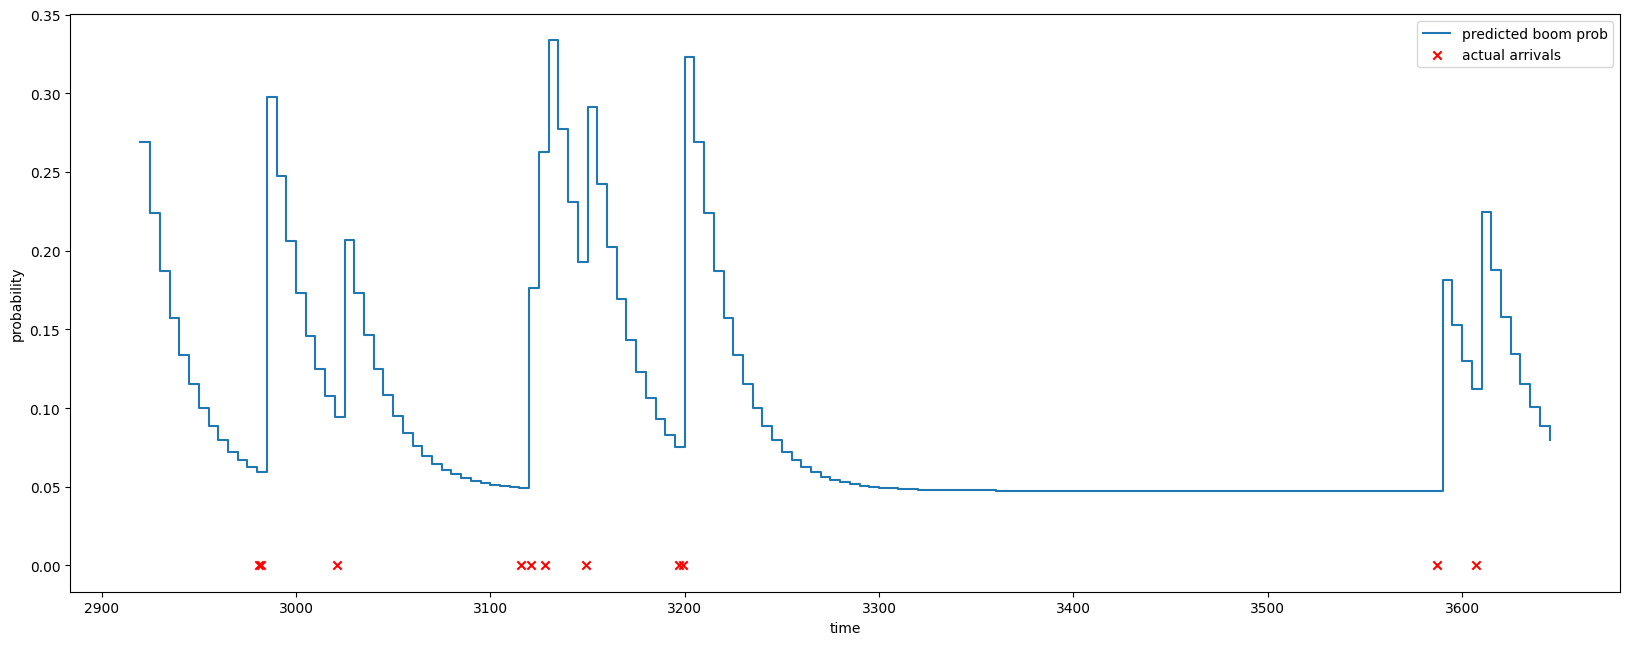

Estimated model parameters: [0.00974  0.039945 0.051207 0.119717 0.427818]
Log-likelihood: -494.5685829030556
QPS: 0.12318900523576114
LPS: 0.2406723962801926
--------------------------------------------------
Fitting model: Exp, Exp, GPD...
Fitted model: Exp, Exp, GPD!


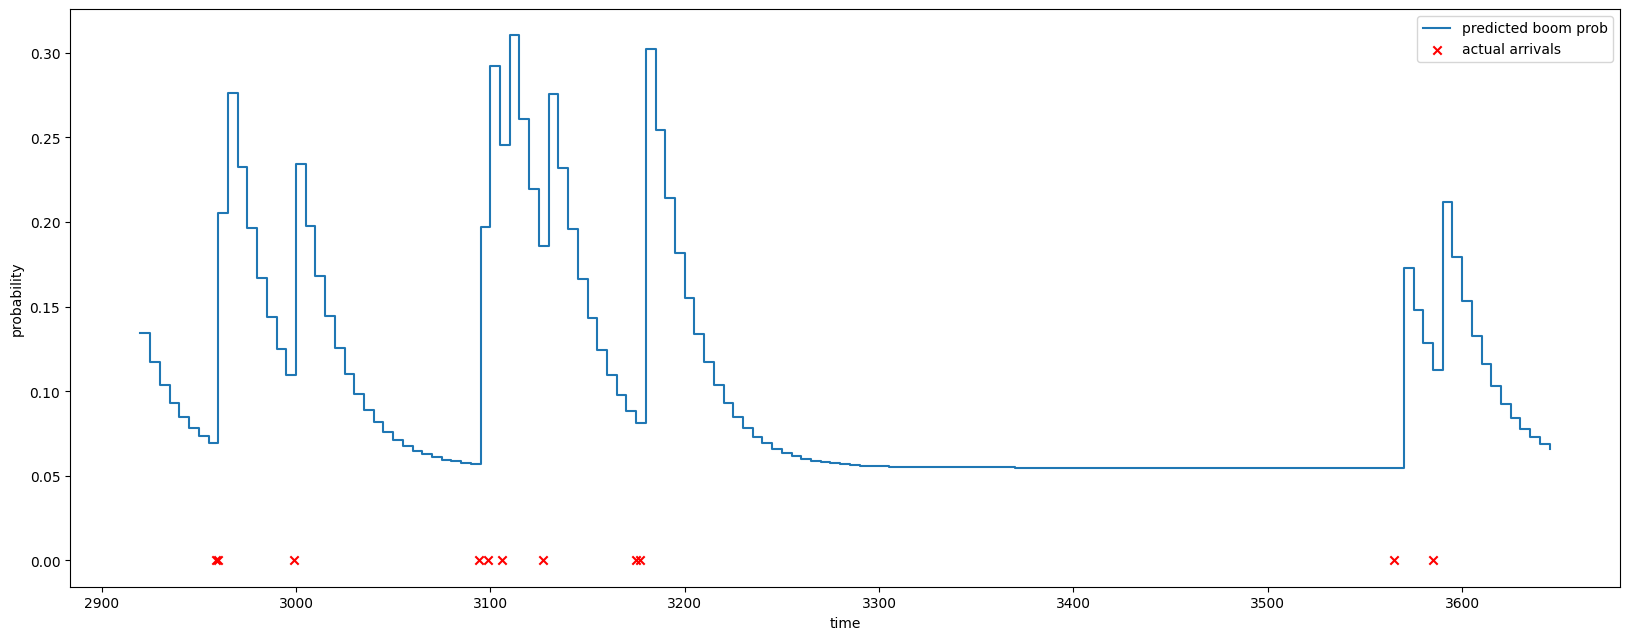

Estimated model parameters: [0.011297 0.038247 0.04986  0.026603 0.094011 0.424297]
Log-likelihood: -561.669803138946
QPS: 0.1295102245855526
LPS: 0.2473526670135945
--------------------------------------------------
Fitting model: Exp, Pow, GPD...
Fitted model: Exp, Pow, GPD!


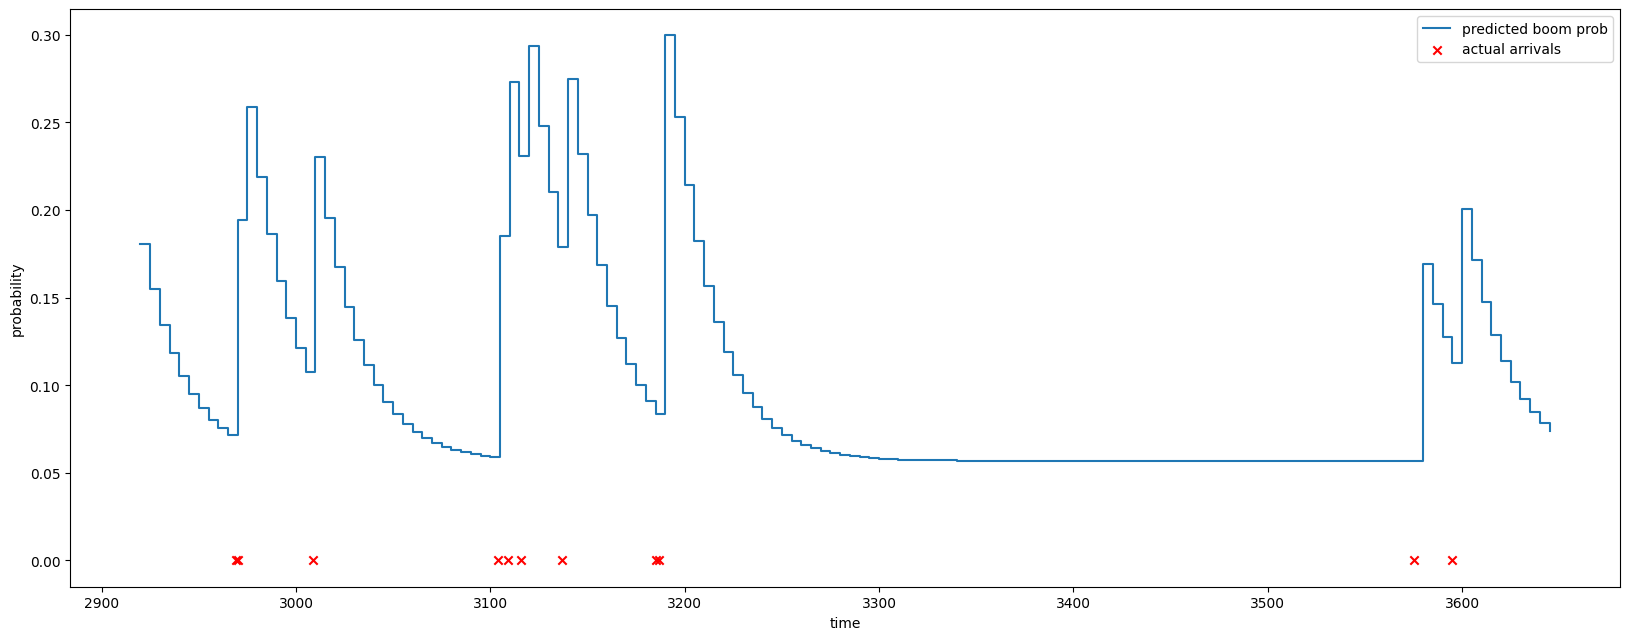

Estimated model parameters: [0.011704 0.033646 0.048979 0.359427 0.104005 0.42635 ]
Log-likelihood: -538.3335808776058
QPS: 0.13033004227484352
LPS: 0.2496427009805907
--------------------------------------------------
Fitting model: Exp, None, SE GPD...
Fitted model: Exp, None, SE GPD!


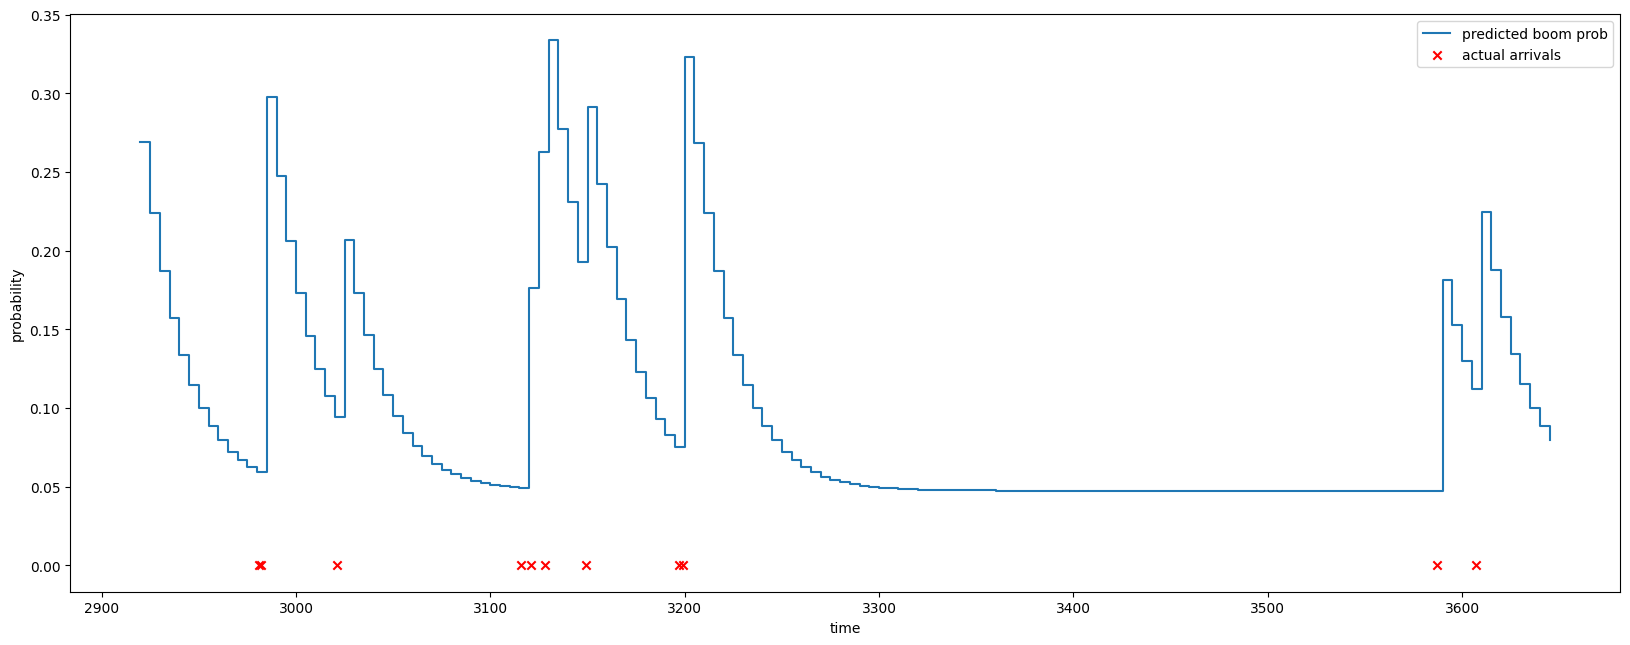

Estimated model parameters: [0.009742 0.039964 0.051235 0.119521 0.431801 0.059698]
Log-likelihood: -497.05232732214847
QPS: 0.1231887687976366
LPS: 0.24067239000641755
--------------------------------------------------
Fitting model: Exp, Exp, SE GPD...
Fitted model: Exp, Exp, SE GPD!


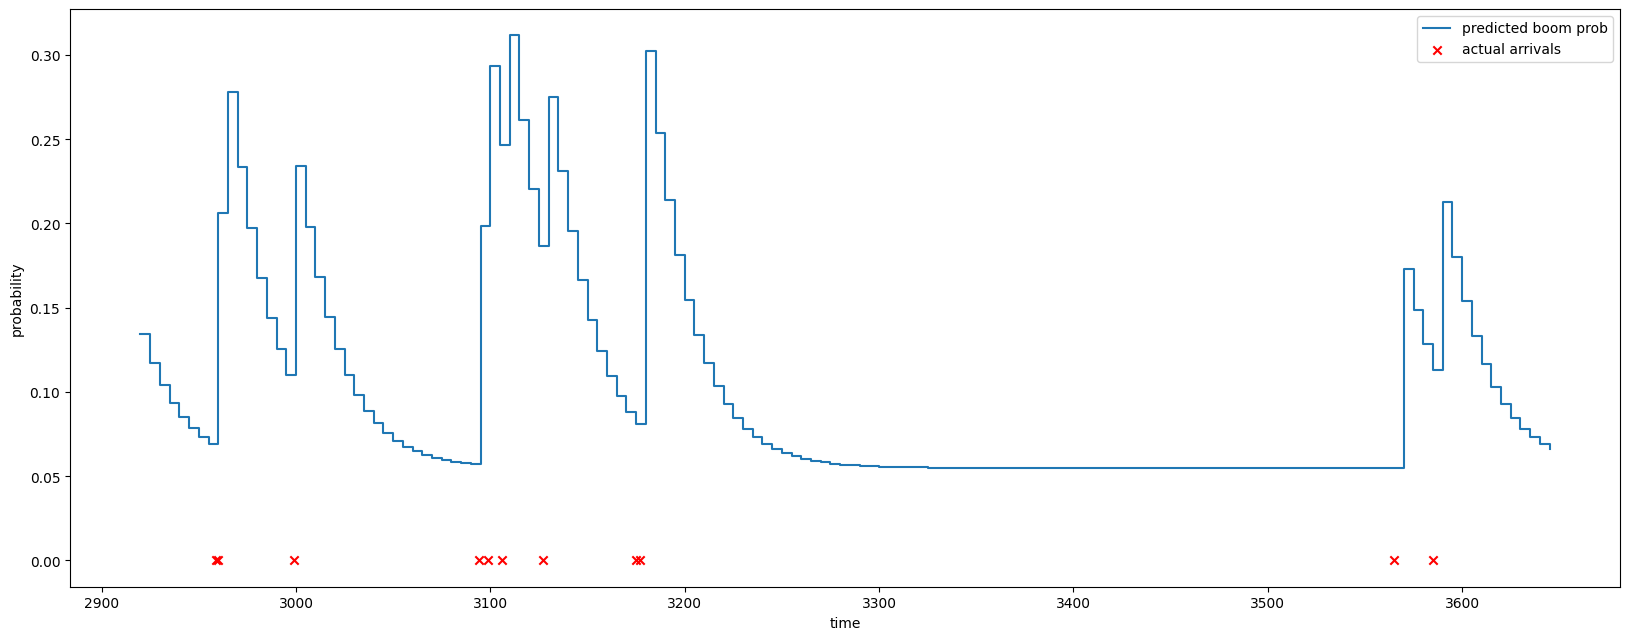

Estimated model parameters: [0.011308 0.038632 0.049945 0.00824  0.091972 0.413904 0.251835]
Log-likelihood: -564.9822819488145
QPS: 0.1294824003315241
LPS: 0.24730518261022794
--------------------------------------------------
Fitting model: Exp, Pow, SE GPD...
Fitted model: Exp, Pow, SE GPD!


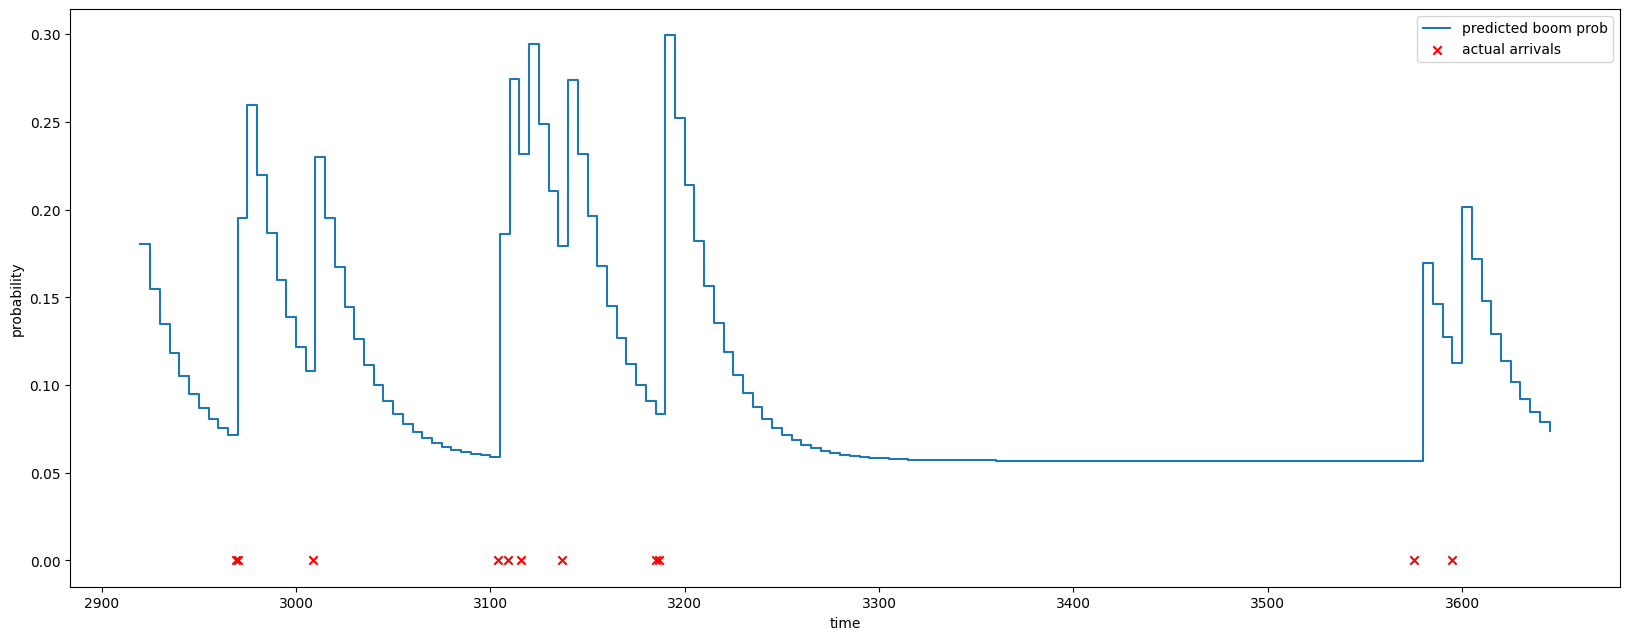

Estimated model parameters: [0.011719 0.033887 0.049046 0.330635 0.103681 0.433025 0.029459]
Log-likelihood: -541.1169007896226
QPS: 0.13029407673580626
LPS: 0.2495883792381056
--------------------------------------------------
Fitting model: Pow, None, GPD...
Fitted model: Pow, None, GPD!


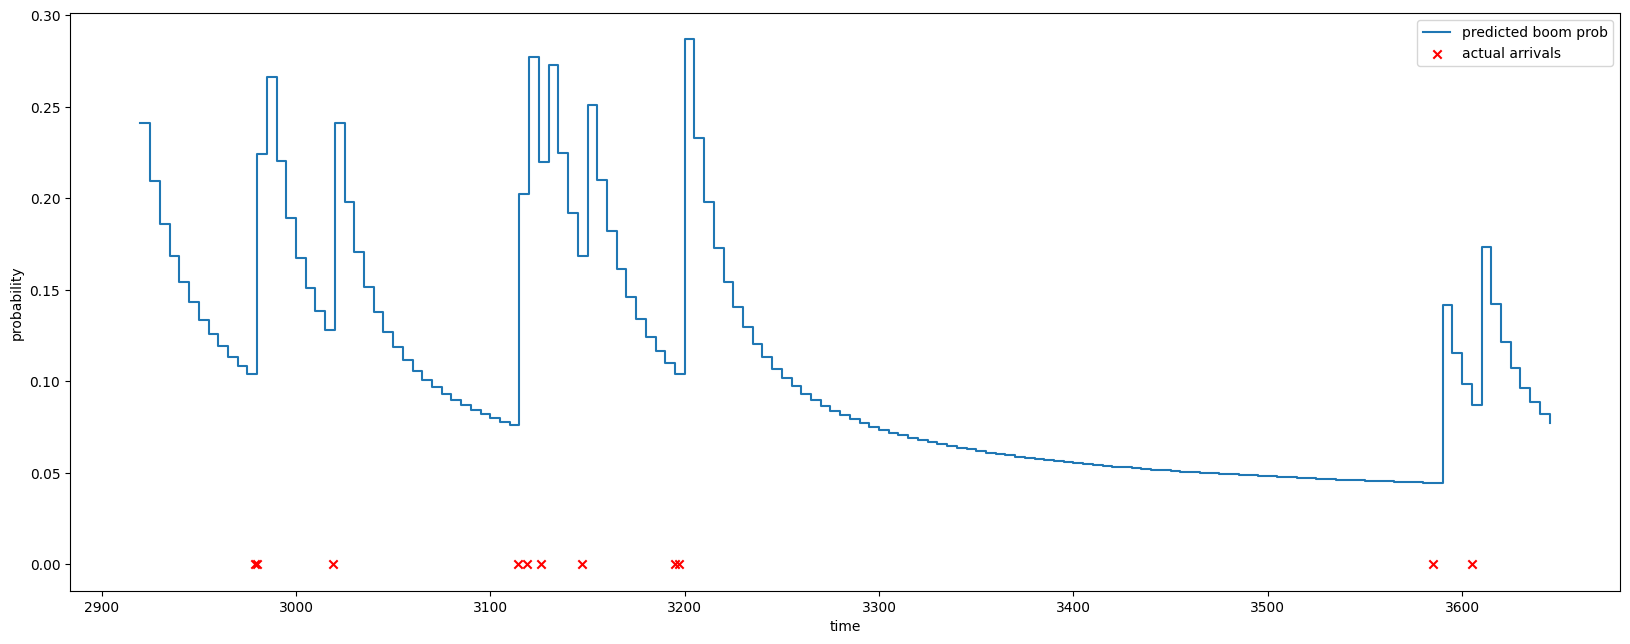

Estimated model parameters: [0.00571  0.04084  0.061703 0.703015 0.104269 0.394576]
Log-likelihood: -498.7821937488227
QPS: 0.129979254907679
LPS: 0.2497473476525416
--------------------------------------------------
Fitting model: Pow, Exp, GPD...
Fitted model: Pow, Exp, GPD!


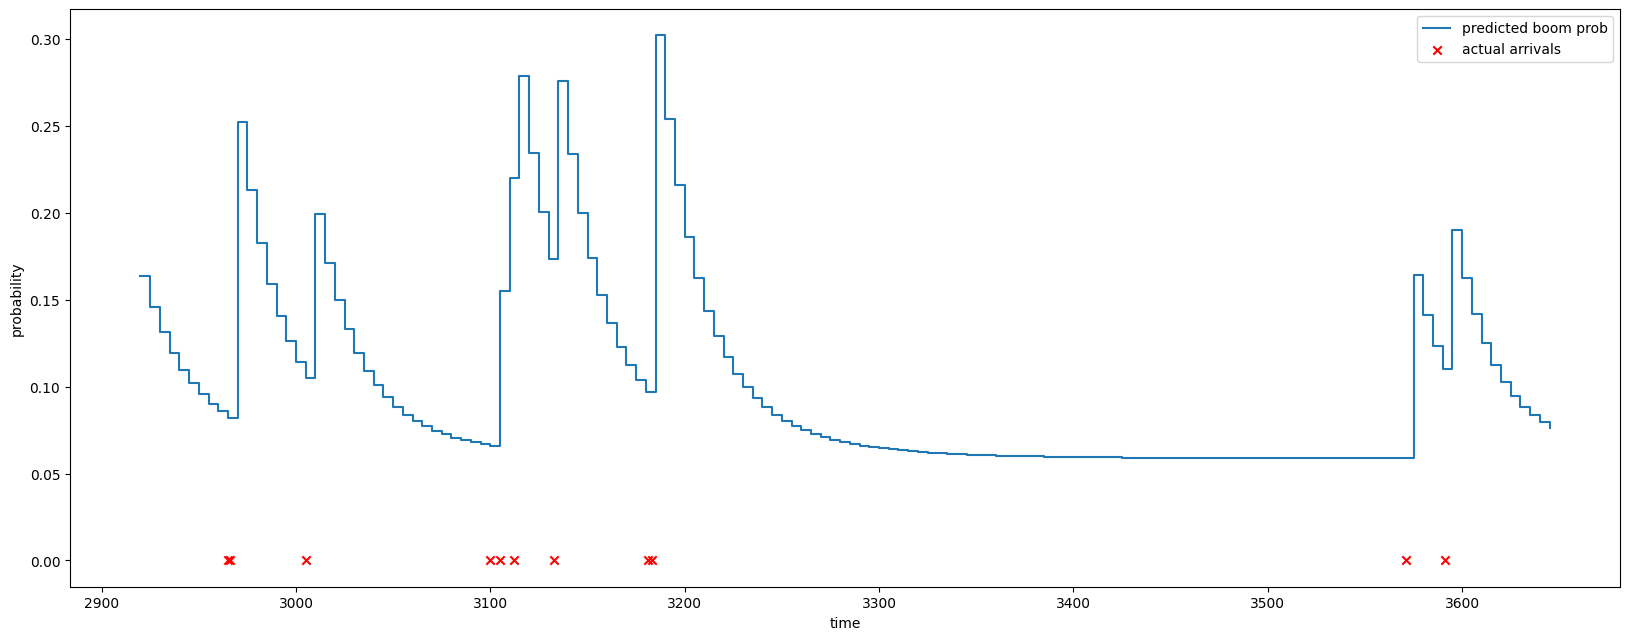

Estimated model parameters: [0.012071 0.030063 0.010812 4.336042 0.314292 0.11633  0.409585]
Log-likelihood: -553.8992175345782
QPS: 0.12120632654450336
LPS: 0.23916308203458916
--------------------------------------------------
Fitting model: Pow, Pow, GPD...
Fitted model: Pow, Pow, GPD!


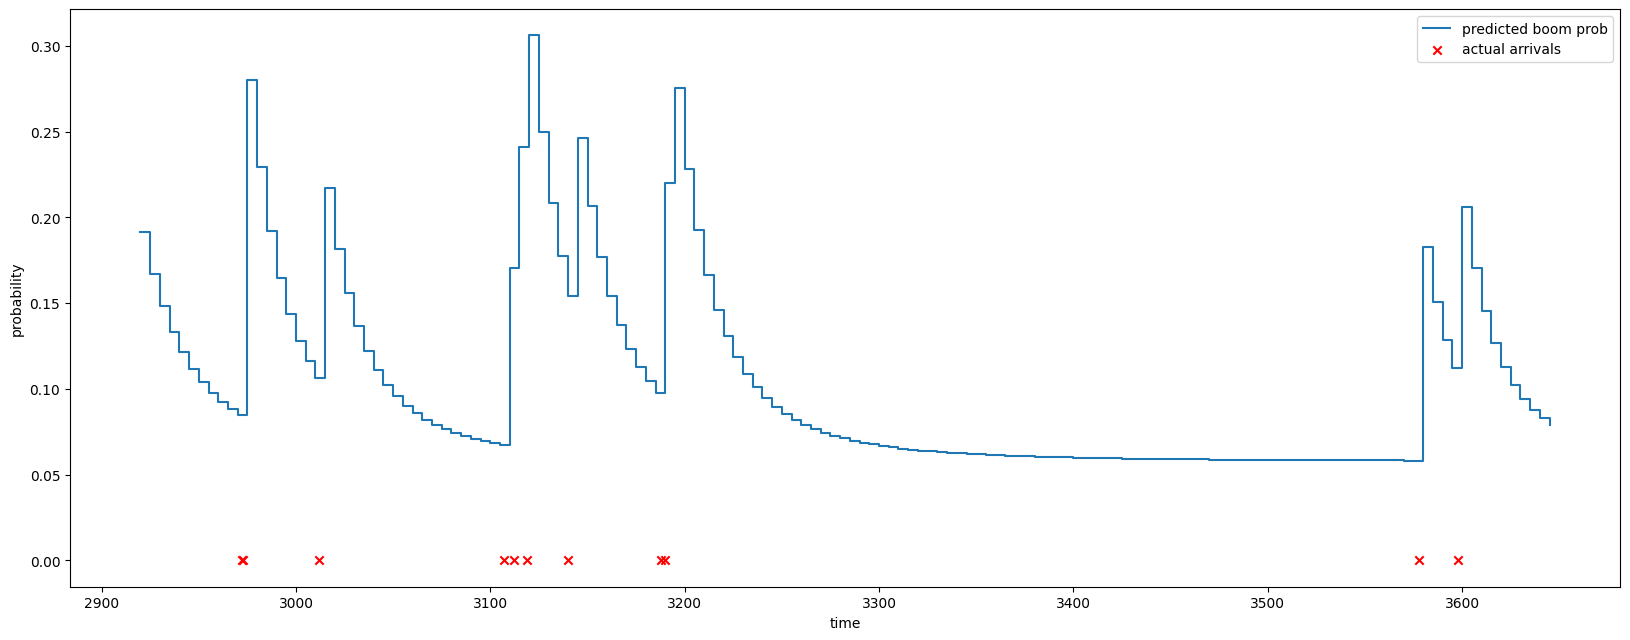

Estimated model parameters: [0.011895 0.033369 0.01966  2.654832 0.602862 0.128744 0.40647 ]
Log-likelihood: -531.8254849249732
QPS: 0.12942569569843512
LPS: 0.24917078040911597
--------------------------------------------------
Fitting model: Pow, None, SE GPD...
Fitted model: Pow, None, SE GPD!


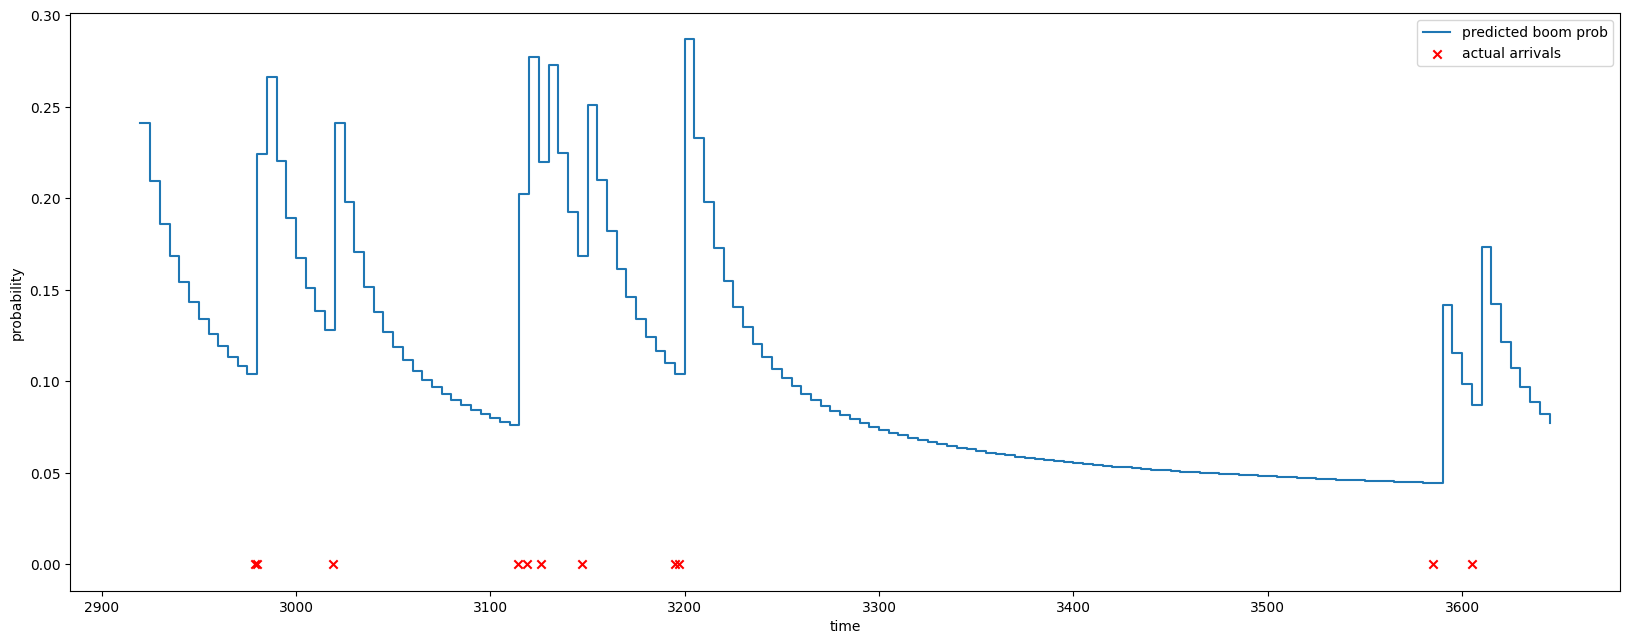

Estimated model parameters: [0.005711 0.040821 0.061645 0.703418 0.104298 0.400636 0.000008]
Log-likelihood: -500.70629233044576
QPS: 0.12998059675662504
LPS: 0.2497494988410925
--------------------------------------------------
Fitting model: Pow, Exp, SE GPD...
Fitted model: Pow, Exp, SE GPD!


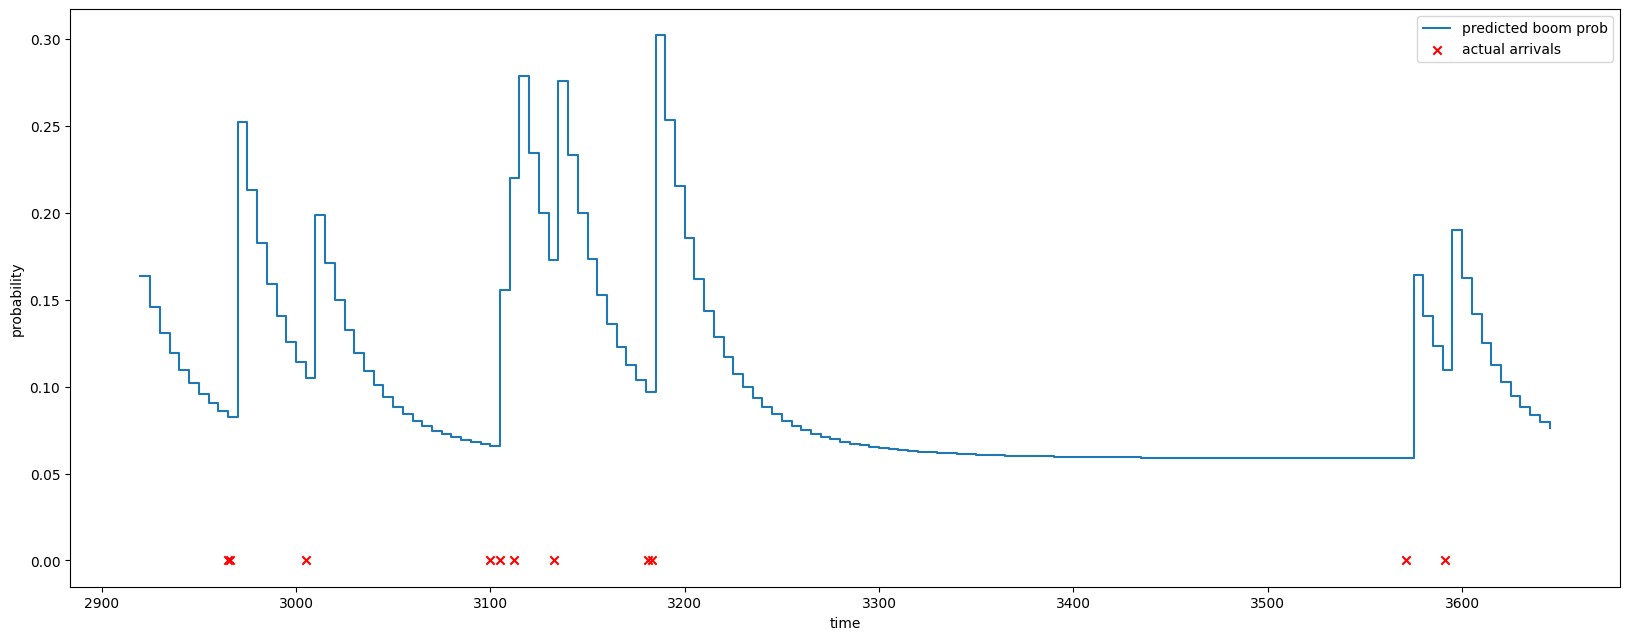

Estimated model parameters: [0.012084 0.030175 0.011091 4.242045 0.30852  0.115552 0.417007 0.000004]
Log-likelihood: -556.2956254121061
QPS: 0.12117866796908708
LPS: 0.23912956244029362
--------------------------------------------------
Fitting model: Pow, Pow, SE GPD...
Fitted model: Pow, Pow, SE GPD!


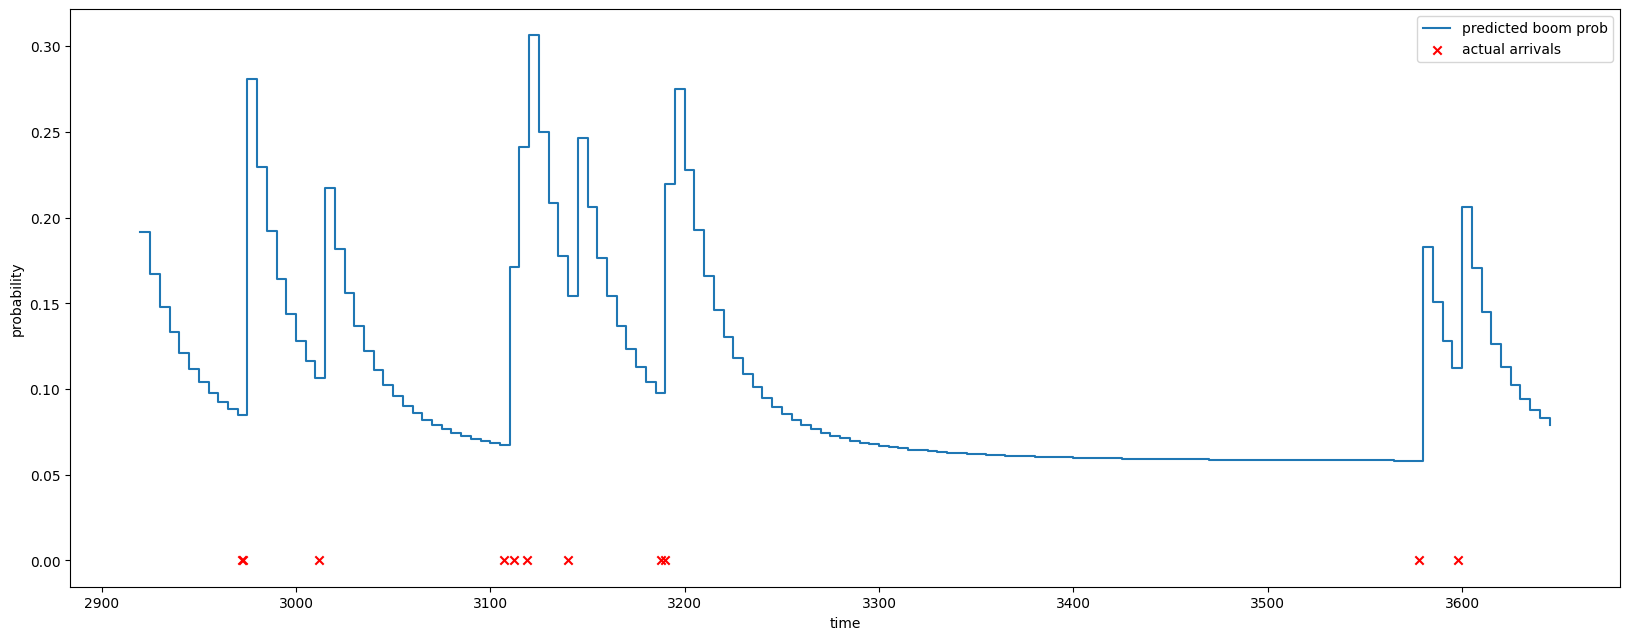

Estimated model parameters: [0.011892 0.033476 0.019924 2.62453  0.591215 0.128233 0.413427 0.00001 ]
Log-likelihood: -534.0296471425609
QPS: 0.12940666534060102
LPS: 0.24914060137547778
--------------------------------------------------


In [5]:
SE_funs = ["Exp", "Pow"]
impact_funs = [None, "Exp", "Pow"]
mark_dists = ["GPD", "SE GPD"]

Results_df = pd.DataFrame()

Results_df.index = ["mu",
                    "K_0",
                    "gamma",
                    "omega",
                    "beta",
                    "alpha",
                    "xi",
                    "phi",
                    "eta",
                    "Branching ratio",
                    "log-like.",
                    "AIC",
                    "KS-test p-value",
                    "KS-test statistic",
                    "QPS on Test Set",
                    "LPS on Test Set"]

Results_df["True Parameters"] = pd.Series("-",
                                          index=Results_df.index,
                                          dtype=object)

Results_df.loc["mu", "True Parameters"] = 0.0063
Results_df.loc["K_0", "True Parameters"] = 0.0446
Results_df.loc["gamma", "True Parameters"] = 0.0331
Results_df.loc["omega", "True Parameters"] = 1.7983
Results_df.loc["beta", "True Parameters"] = 0.0531
Results_df.loc["alpha", "True Parameters"] = 0.1388
Results_df.loc["xi", "True Parameters"] = 0.1157
Results_df.loc["phi", "True Parameters"] = 0.3870
Results_df.loc["eta", "True Parameters"] = 0.0911

for SE_fun in SE_funs:
    for mark_dist in mark_dists:
        for impact_fun in impact_funs:
            true_params, _, _ = get_true_params(SE_fun=SE_fun,
                                                impact_fun=impact_fun,
                                                mark_dist=mark_dist)
            
            simulator = simulate_SE_POT(T=T,
                                        threshold=threshold,
                                        params=true_params,
                                        SE_fun=SE_fun,
                                        impact_fun=impact_fun,
                                        mark_dist=mark_dist,
                                        seed=seed)
            arrival_times, marks = simulator.simulate()

            train_size_percentage = 0.8

            train_T = int(train_size_percentage * T)

            test_T = T

            train_mask = arrival_times < train_T

            test_mask = ~train_mask

            train_arrival_times, train_marks = arrival_times[train_mask], marks[train_mask]

            test_arrival_times, test_marks = arrival_times[test_mask], marks[test_mask]


            SEPOT_model = SEPOT(SE_fun=SE_fun,
                                impact_fun=impact_fun,
                                mark_dist=mark_dist,
                                arrival_times=train_arrival_times,
                                marks=train_marks,
                                T=train_T,
                                threshold=threshold)
            
            print(f"Fitting model: {SE_fun}, {impact_fun}, {mark_dist}...")

            res = SEPOT_model.fit(method="L-BFGS-B",
                                  reparam=True,
                                  xi_pos=True,
                                  seed=1)
            
            print(f"Fitted model: {SE_fun}, {impact_fun}, {mark_dist}!")
            
            est_params = res.x

            log_likelihood = -res.fun
            AIC = 2 * len(est_params) - 2 * (log_likelihood)

            tau_i_s = SEPOT_model.compensator(starts=np.zeros(shape=(len(arrival_times), ), dtype=float),
                                              ends=arrival_times,
                                              params=est_params)

            interarrival_times = tau_i_s - np.concatenate([[0],
                                                            tau_i_s[:-1]])

            pvalue = kstest(rvs=interarrival_times,
                            cdf="expon").pvalue
            test_stat = kstest(rvs=interarrival_times,
                            cdf="expon").statistic
            
            Results_df[f"{SE_fun}, {impact_fun}, {mark_dist}"] = pd.Series("-",
                                                                           index=Results_df.index,
                                                                           dtype=object)

            if SE_fun == "Exp":
                Results_df.loc["Branching ratio", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]/est_params[2]
            else:
                Results_df.loc["Branching ratio", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]/(est_params[2] * est_params[3])

            Results_df.loc["log-like.", f"{SE_fun}, {impact_fun}, {mark_dist}"] = log_likelihood
            Results_df.loc["AIC", f"{SE_fun}, {impact_fun}, {mark_dist}"] = AIC
            Results_df.loc["KS-test p-value", f"{SE_fun}, {impact_fun}, {mark_dist}"] = pvalue
            Results_df.loc["KS-test statistic", f"{SE_fun}, {impact_fun}, {mark_dist}"] = test_stat

            Results_df.loc["mu", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[0]
            Results_df.loc["K_0", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]
            if SE_fun == "Exp":
                Results_df.loc["beta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[2]
                if impact_fun is not None:
                    Results_df.loc["alpha", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]
                else:
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]

            else:
                Results_df.loc["gamma", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[2]
                Results_df.loc["omega", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                if impact_fun is not None:
                    Results_df.loc["alpha", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[7]
                else:
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]

            preds, y = SEPOT_model.rolling_forecast(start=train_T,
                                                    days=5,
                                                    params=est_params,
                                                    test_arrival_times=test_arrival_times,
                                                    test_marks=test_marks,
                                                    test_T=test_T)
            
            QPS = 2/len(y) * ((preds - y)**2).sum()
            LPS = -1/len(y) * ((1 - y) * np.log(1 - preds) + y * np.log(preds)).sum()

            Results_df.loc["QPS on Test Set", f"{SE_fun}, {impact_fun}, {mark_dist}"] = QPS
            Results_df.loc["LPS on Test Set", f"{SE_fun}, {impact_fun}, {mark_dist}"] = LPS

            chunk_starts = np.arange(train_T, test_T, 5)[:len(preds)]
            chunk_ends = np.minimum(chunk_starts + 5, test_T)

            plt.figure(figsize=(20, 7.5), dpi=100)
            plt.step(chunk_starts, preds, where='post', label='predicted boom prob')
            plt.scatter(test_arrival_times, np.zeros_like(test_arrival_times),
                        color='red', marker='x', label='actual arrivals')
            plt.xlabel('time')
            plt.ylabel('probability')
            plt.legend()
            plt.show()
            
            print(f"Estimated model parameters: {est_params}")
            print(f"Log-likelihood: {log_likelihood}")
            print(f"QPS: {QPS}")
            print(f"LPS: {LPS}")
            print("-"*50)


In [6]:
Results_df

,True Parameters,"Exp, None, GPD","Exp, Exp, GPD","Exp, Pow, GPD","Exp, None, SE GPD","Exp, Exp, SE GPD","Exp, Pow, SE GPD","Pow, None, GPD","Pow, Exp, GPD","Pow, Pow, GPD","Pow, None, SE GPD","Pow, Exp, SE GPD","Pow, Pow, SE GPD"
mu,0.006300,0.009740,0.011297,0.011704,0.009742,0.011308,0.011719,0.005710,0.012071,0.011895,0.005711,0.012084,0.011892
K_0,0.044600,0.039945,0.038247,0.033646,0.039964,0.038632,0.033887,0.040840,0.030063,0.033369,0.040821,0.030175,0.033476
gamma,0.033100,-,-,-,-,-,-,0.061703,0.010812,0.019660,0.061645,0.011091,0.019924
omega,1.798300,-,-,-,-,-,-,0.703015,4.336042,2.654832,0.703418,4.242045,2.624530
beta,0.053100,0.051207,0.049860,0.048979,0.051235,0.049945,0.049046,-,-,-,-,-,-
alpha,0.138800,-,0.026603,0.359427,-,0.008240,0.330635,-,0.314292,0.602862,-,0.308520,0.591215
xi,0.115700,0.119717,0.094011,0.104005,0.119521,0.091972,0.103681,0.104269,0.116330,0.128744,0.104298,0.115552,0.128233
phi,0.387000,0.427818,0.424297,0.426350,0.431801,0.413904,0.433025,0.394576,0.409585,0.406470,0.400636,0.417007,0.413427
eta,0.091100,-,-,-,0.059698,0.251835,0.029459,-,-,-,0.000008,0.000004,0.000010
Branching ratio,-,0.780071,0.767097,0.686954,0.780014,0.773482,0.690918,0.941489,0.641272,0.639343,0.941396,0.641355,0.640198
